# Orthogonal Linear Probe Basis: Normal GPTCV Setup

This notebook runs the ordered orthogonal linear-probe basis experiment on the original continuous Kepler GPTCV model, not on the static/dynamic split model.

The latent source is the normal model residual stream. By default we use `after_ln_f`, whose dimension is `n_embd=32`.

In [1]:
import os
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.linalg import null_space
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from kepler_cv import compute_gravitational_force, load_trajectories, setup_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

Using device: cpu


device(type='cpu')

## Configuration

In [2]:
args = Namespace(
    num_trajectories=100,
    n_steps=3000,
    batch_size=64,
    lr=1e-3,
    weight_decay=0.0,
    noise_scale=0.1,
    n_layer=2,
    n_embd=32,
    log_freq=250,
    seed=1,
    output_dir="results/orthogonal_linear_probe_basis_normal",
)

TARGET_NAME = "r"
LATENT_SOURCE = "after_ln_f"
TRAJECTORY_ID = 0

np.random.seed(args.seed)
torch.manual_seed(args.seed)
os.makedirs(args.output_dir, exist_ok=True)
args

Namespace(num_trajectories=100, n_steps=3000, batch_size=64, lr=0.001, weight_decay=0.0, noise_scale=0.1, n_layer=2, n_embd=32, log_freq=250, seed=1, output_dir='results/orthogonal_linear_probe_basis_normal')

## Load Data

In [3]:
def split_normal_dataset(num_trajectories):
    trajectories = load_trajectories("data_cv", num_trajectories_needed=2 * num_trajectories)
    num_loaded = trajectories.shape[0]
    train_trajectories = trajectories[:num_loaded // 2]
    test_trajectories = trajectories[num_loaded // 2:]

    train_inputs = torch.from_numpy(train_trajectories[:, :-1]).float()
    train_targets = torch.from_numpy(train_trajectories[:, 1:]).float()
    test_inputs = torch.from_numpy(test_trajectories[:, :-1]).float()
    test_targets = torch.from_numpy(test_trajectories[:, 1:]).float()

    return train_trajectories, test_trajectories, train_inputs, train_targets, test_inputs, test_targets


train_trajectories, test_trajectories, train_inputs, train_targets, test_inputs, test_targets = split_normal_dataset(args.num_trajectories)
print("train_inputs", train_inputs.shape)
print("test_inputs", test_inputs.shape)

Loading 200 trajectories from 1 chunks...
Loaded 200 trajectories from chunks
train_inputs torch.Size([100, 99, 2])
test_inputs torch.Size([100, 99, 2])


In [4]:
# Debug: dataset and next-step-prediction tensor shapes
print("train_trajectories", train_trajectories.shape)
print("test_trajectories", test_trajectories.shape)
print("train_inputs", train_inputs.shape)
print("train_targets", train_targets.shape)
print("test_inputs", test_inputs.shape)
print("test_targets", test_targets.shape)
print("one input trajectory", train_inputs[TRAJECTORY_ID].shape)


train_trajectories (100, 100, 2)
test_trajectories (100, 100, 2)
train_inputs torch.Size([100, 99, 2])
train_targets torch.Size([100, 99, 2])
test_inputs torch.Size([100, 99, 2])
test_targets torch.Size([100, 99, 2])
one input trajectory torch.Size([99, 2])


## Train Normal GPTCV Model

In [5]:
model = setup_model(n_layer=args.n_layer, n_embd=args.n_embd, device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

train_losses = []
test_losses = []

for step in range(args.n_steps):
    if step == args.n_steps // 2:
        for group in optimizer.param_groups:
            group["lr"] *= 0.1

    model.train()
    batch_indices = torch.randint(0, train_inputs.shape[0], (args.batch_size,))
    batch_inputs = train_inputs[batch_indices].to(device)
    batch_targets = train_targets[batch_indices].to(device)
    batch_inputs = batch_inputs + torch.randn_like(batch_inputs) * args.noise_scale

    _, loss = model(batch_inputs, batch_targets)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    train_losses.append(float(loss.item()))

    model.eval()
    with torch.no_grad():
        test_indices = torch.randint(0, test_inputs.shape[0], (args.batch_size,))
        _, test_loss = model(test_inputs[test_indices].to(device), test_targets[test_indices].to(device))
        test_losses.append(float(test_loss.item()))

    if step % args.log_freq == 0 or step == args.n_steps - 1:
        print(
            f"Step {step + 1:4d}/{args.n_steps}, "
            f"train loss {train_losses[-1]:.6f}, test loss {test_losses[-1]:.6f}"
        )

checkpoint_path = os.path.join(args.output_dir, "normal_gptcv_model_state.pt")
torch.save({"model_state_dict": model.state_dict(), "args": vars(args)}, checkpoint_path)
print(f"Saved checkpoint to {checkpoint_path}")

number of parameters: 0.025634M


Step    1/3000, train loss 1.111579, test loss 0.748480


Step  251/3000, train loss 0.012432, test loss 0.003487


Step  501/3000, train loss 0.010602, test loss 0.002877


Step  751/3000, train loss 0.009962, test loss 0.003316


...

Step 2001/3000, train loss 0.006609, test loss 0.002483


Step 2251/3000, train loss 0.006216, test loss 0.001771


Step 2501/3000, train loss 0.006315, test loss 0.001925


Step 2751/3000, train loss 0.006301, test loss 0.001841


Step 3000/3000, train loss 0.006118, test loss 0.001972
Saved checkpoint to results/orthogonal_linear_probe_basis_normal/normal_gptcv_model_state.pt


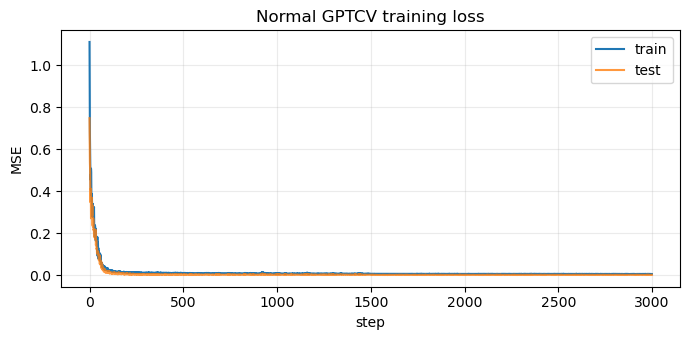

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(train_losses, label="train")
ax.plot(test_losses, label="test", alpha=0.8)
ax.set_xlabel("step")
ax.set_ylabel("MSE")
ax.set_title("Normal GPTCV training loss")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

## Extract Normal Model Latents

In [7]:
@torch.no_grad()
def extract_gptcv_latents(model, inputs, source="after_ln_f"):
    model.eval()
    x = inputs.to(device)
    if x.dim() == 2:
        x = x.unsqueeze(-1)

    _, time_steps, _ = x.shape
    pos = torch.arange(0, time_steps, dtype=torch.long, device=x.device)
    h = model.input_embedding(x)
    if source == "input_embed":
        return h.cpu().numpy()

    h = model.transformer.drop(h + model.transformer.wpe(pos))
    if source == "after_pos_emb":
        return h.cpu().numpy()

    for block_idx, block in enumerate(model.transformer.h):
        h = block(h)
        if source == f"block_{block_idx}_after_mlp_merge":
            return h.cpu().numpy()

    h = model.transformer.ln_f(h)
    if source == "after_ln_f":
        return h.cpu().numpy()

    raise ValueError(f"Unknown latent source: {source}")


z_train = extract_gptcv_latents(model, train_inputs, source=LATENT_SOURCE)
z_test = extract_gptcv_latents(model, test_inputs, source=LATENT_SOURCE)

dynamic_values_train = compute_gravitational_force(train_inputs.numpy())
dynamic_values_test = compute_gravitational_force(test_inputs.numpy())

X_train = z_train.reshape(-1, z_train.shape[-1])
y_train = dynamic_values_train[TARGET_NAME].reshape(-1)
X_test = z_test.reshape(-1, z_test.shape[-1])
y_test = dynamic_values_test[TARGET_NAME].reshape(-1)

print("latent source", LATENT_SOURCE)
print("z_train", z_train.shape)
print("X_train", X_train.shape, "y_train", y_train.shape)
print("target", TARGET_NAME, "mean", float(y_train.mean()), "std", float(y_train.std()))

latent source after_ln_f
z_train (100, 99, 32)
X_train (9900, 32) y_train (9900,)
target r mean 1.444868564605713 std 0.6384714245796204


In [8]:
# Debug: latent and probe-target shapes
print("z_train", z_train.shape)
print("z_test", z_test.shape)
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)
print("target", TARGET_NAME, "train mean/std", float(y_train.mean()), float(y_train.std()))


z_train (100, 99, 32)
z_test (100, 99, 32)
X_train (9900, 32)
X_test (9900, 32)
y_train (9900,)
y_test (9900,)
target r train mean/std 1.444868564605713 0.6384714245796204


## Sequential Orthogonal Linear Probes

In [9]:
def orthogonal_complement_basis(V_prev, dim, atol=1e-10):
    if V_prev.size == 0:
        return np.eye(dim)
    Q = null_space(V_prev.T, rcond=atol)
    if Q.shape[1] == 0:
        raise ValueError("No dimensions left in the orthogonal complement.")
    return Q


def fit_ordered_orthogonal_probe_basis(X, y, n_directions=None):
    dim = X.shape[1]
    if n_directions is None:
        n_directions = dim

    directions = []
    records = []

    for direction_id in range(n_directions):
        V_prev = np.column_stack(directions) if directions else np.empty((dim, 0))
        Q = orthogonal_complement_basis(V_prev, dim)
        X_sub = X @ Q

        probe = LinearRegression(fit_intercept=True)
        probe.fit(X_sub, y)
        y_pred = probe.predict(X_sub)

        w_full = Q @ probe.coef_.reshape(-1)
        w_norm = np.linalg.norm(w_full)
        if w_norm < 1e-12:
            raise ValueError(f"Direction {direction_id} has near-zero weight norm.")

        v = w_full / w_norm
        directions.append(v)
        records.append({
            "direction_id": direction_id,
            "remaining_dim": Q.shape[1],
            "mse": float(mean_squared_error(y, y_pred)),
            "r2": float(r2_score(y, y_pred)),
            "intercept": float(probe.intercept_),
            "weight_norm": float(w_norm),
        })

    V = np.column_stack(directions)
    return V, records


V, probe_records = fit_ordered_orthogonal_probe_basis(X_train, y_train)
orthogonality_error = np.max(np.abs(V.T @ V - np.eye(V.shape[1])))
print("V shape", V.shape)
print("max |V.T @ V - I|", orthogonality_error)
probe_records[:5]

V shape (32, 32)
max |V.T @ V - I| 4.440892098500626e-16


[{'direction_id': 0,
  'remaining_dim': 32,
  'mse': 0.08918663566583711,
  'r2': 0.781215371018595,
  'intercept': -95.05963456319546,
  'weight_norm': 8349.104652089847},
 {'direction_id': 1,
  'remaining_dim': 31,
  'mse': 0.08918769502944542,
  'r2': 0.7812127722831199,
  'intercept': 2.689502485611632,
  'weight_norm': 1.036180953459054},
 {'direction_id': 2,
  'remaining_dim': 30,
  'mse': 0.12237189735389808,
  'r2': 0.6998082732861892,
  'intercept': 2.778840879600681,
  'weight_norm': 1.0585224102013602},
 {'direction_id': 3,
  'remaining_dim': 29,
  'mse': 0.16848231345441675,
  'r2': 0.5866943498444681,
  'intercept': 2.4853701764518314,
  'weight_norm': 1.348627155026335},
 {'direction_id': 4,
  'remaining_dim': 28,
  'mse': 0.2397626856166421,
  'r2': 0.41183575515994375,
  'intercept': 2.1630399141036163,
  'weight_norm': 1.219141943671856}]

In [10]:
# Debug: ordered orthogonal basis shapes
print("X_train", X_train.shape)
print("V", V.shape)
print("number of probe records", len(probe_records))
print("first record keys", sorted(probe_records[0].keys()))
print("orthogonality matrix", (V.T @ V).shape)
print("max orthogonality error", orthogonality_error)


X_train (9900, 32)
V (32, 32)
number of probe records 32
first record keys ['direction_id', 'intercept', 'mse', 'r2', 'remaining_dim', 'weight_norm']
orthogonality matrix (32, 32)
max orthogonality error 4.440892098500626e-16


First 10 probe records:
{'direction_id': 0, 'remaining_dim': 32, 'mse': 0.08918663566583711, 'r2': 0.781215371018595, 'intercept': -95.05963456319546, 'weight_norm': 8349.104652089847}
{'direction_id': 1, 'remaining_dim': 31, 'mse': 0.08918769502944542, 'r2': 0.7812127722831199, 'intercept': 2.689502485611632, 'weight_norm': 1.036180953459054}
{'direction_id': 2, 'remaining_dim': 30, 'mse': 0.12237189735389808, 'r2': 0.6998082732861892, 'intercept': 2.778840879600681, 'weight_norm': 1.0585224102013602}
{'direction_id': 3, 'remaining_dim': 29, 'mse': 0.16848231345441675, 'r2': 0.5866943498444681, 'intercept': 2.4853701764518314, 'weight_norm': 1.348627155026335}
{'direction_id': 4, 'remaining_dim': 28, 'mse': 0.2397626856166421, 'r2': 0.41183575515994375, 'intercept': 2.1630399141036163, 'weight_norm': 1.219141943671856}
{'direction_id': 5, 'remaining_dim': 27, 'mse': 0.27867690521846405, 'r2': 0.31637489340499414, 'intercept': 2.1786887290800596, 'weight_norm': 1.182018299617116}
{'dir

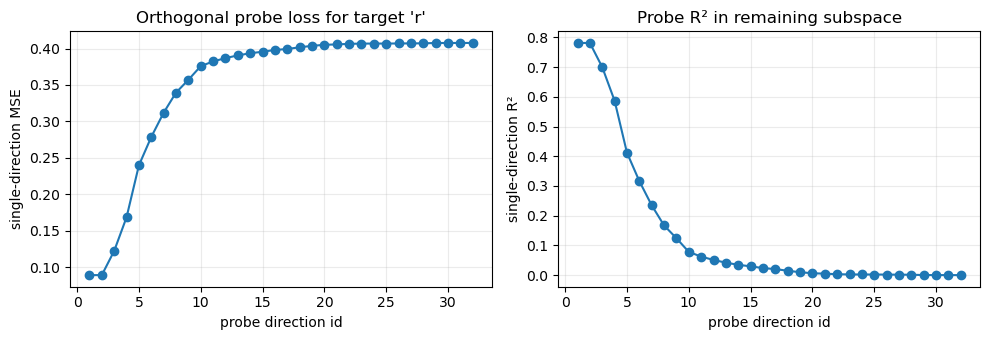

In [11]:
losses = np.array([row["mse"] for row in probe_records])
r2s = np.array([row["r2"] for row in probe_records])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(np.arange(1, len(losses) + 1), losses, marker="o")
axes[0].set_xlabel("probe direction id")
axes[0].set_ylabel("single-direction MSE")
axes[0].set_title(f"Orthogonal probe loss for target {TARGET_NAME!r}")
axes[0].grid(alpha=0.25)

axes[1].plot(np.arange(1, len(r2s) + 1), r2s, marker="o")
axes[1].set_xlabel("probe direction id")
axes[1].set_ylabel("single-direction R²")
axes[1].set_title("Probe R² in remaining subspace")
axes[1].grid(alpha=0.25)

fig.tight_layout()
print("First 10 probe records:")
for row in probe_records[:10]:
    print(row)

## Probe Remaining Target Variables

Run the same ordered orthogonal probe procedure for every remaining target from `compute_gravitational_force`, without overwriting the main `V` for `TARGET_NAME`.


In [12]:
ALL_TARGET_NAMES = list(dynamic_values_train.keys())
OTHER_TARGET_NAMES = [name for name in ALL_TARGET_NAMES if name != TARGET_NAME]

print("all targets", ALL_TARGET_NAMES)
print("main target", TARGET_NAME)
print("other targets", OTHER_TARGET_NAMES)


all targets ['Fx', 'Fy', 'F_magnitude', 'F_direction_x', 'F_direction_y', 'r', 'inv_r', 'r_squared', 'inv_r_squared', 'inv_r_cubed', 'x', 'y']
main target r
other targets ['Fx', 'Fy', 'F_magnitude', 'F_direction_x', 'F_direction_y', 'inv_r', 'r_squared', 'inv_r_squared', 'inv_r_cubed', 'x', 'y']


In [13]:
other_target_probe_results = {}

for target_name in OTHER_TARGET_NAMES:
    y_other = dynamic_values_train[target_name].reshape(-1)
    print("\n===", target_name, "===")
    print("y", y_other.shape, "mean/std", float(y_other.mean()), float(y_other.std()))

    V_other, records_other = fit_ordered_orthogonal_probe_basis(X_train, y_other)
    orthogonality_error_other = np.max(np.abs(V_other.T @ V_other - np.eye(V_other.shape[1])))

    other_target_probe_results[target_name] = {
        "V": V_other,
        "probe_records": records_other,
        "orthogonality_error": orthogonality_error_other,
        "target_mean": float(y_other.mean()),
        "target_std": float(y_other.std()),
    }

    print("V", V_other.shape)
    print("max orthogonality error", orthogonality_error_other)
    print("first direction", records_other[0])



=== Fx ===
y (9900,) mean/std -0.028014130890369415 2.02815580368042


V (32, 32)
max orthogonality error 4.440892098500626e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 3.1927868315724597, 'r2': 0.22381146095695914, 'intercept': 837.0258832289911, 'weight_norm': 71520.5978830661}

=== Fy ===
y (9900,) mean/std 0.024174584075808525 1.695515513420105


V (32, 32)
max orthogonality error 4.440892098500626e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 2.0329403357645046, 'r2': 0.29283445694869104, 'intercept': -937.4504954852363, 'weight_norm': 80081.51652744795}

=== F_magnitude ===
y (9900,) mean/std 1.1115832328796387 2.3987374305725098


V (32, 32)
max orthogonality error 4.596445428217054e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 4.807305863566071, 'r2': 0.16451952136618975, 'intercept': 1293.9372766253746, 'weight_norm': 110573.69078233617}

=== F_direction_x ===
y (9900,) mean/std 0.008967823348939419 0.7117524147033691


V (32, 32)
max orthogonality error 3.3306690738754696e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.013950624007189098, 'r2': 0.9724617897841583, 'intercept': 229.75021193368963, 'weight_norm': 19627.338580154108}

=== F_direction_y ===
y (9900,) mean/std -0.01916607841849327 0.7021116018295288


...

V (32, 32)
max orthogonality error 3.7431383861442687e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 1.0438331140075436, 'r2': 0.7424765863533787, 'intercept': -554.5350428840045, 'weight_norm': 47908.57230215723}

=== inv_r_squared ===
y (9900,) mean/std 1.1115831136703491 2.3987374305725098


V (32, 32)
max orthogonality error 4.440892098500626e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 4.807305748054391, 'r2': 0.16451952313709717, 'intercept': 1293.9370234743908, 'weight_norm': 110573.66916039895}

=== inv_r_cubed ===
y (9900,) mean/std 2.1454391479492188 14.565893173217773


V (32, 32)
max orthogonality error 5.551115123125783e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 203.0668923995125, 'r2': 0.042883429569769094, 'intercept': 11469.305472482833, 'weight_norm': 979745.2805907256}

=== x ===
y (9900,) mean/std -0.026397041976451874 1.1348950862884521


V (32, 32)
max orthogonality error 4.440892098500626e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.0018153703321233381, 'r2': 0.9985905363698699, 'intercept': 48.20008147149425, 'weight_norm': 4119.395878816037}

=== y ===
y (9900,) mean/std 0.037333354353904724 1.0978223085403442


V (32, 32)
max orthogonality error 5.551115123125783e-16
first direction {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.0015566162182947137, 'r2': 0.998708431470808, 'intercept': 141.3248143177303, 'weight_norm': 12070.580559359178}


In [14]:
other_target_summary = []
for target_name, result in other_target_probe_results.items():
    records = result["probe_records"]
    losses_other = np.array([row["mse"] for row in records])
    r2s_other = np.array([row["r2"] for row in records])
    other_target_summary.append({
        "target": target_name,
        "target_std": result["target_std"],
        "direction_0_mse": float(losses_other[0]),
        "direction_0_r2": float(r2s_other[0]),
        "last_direction_mse": float(losses_other[-1]),
        "last_direction_r2": float(r2s_other[-1]),
        "orthogonality_error": float(result["orthogonality_error"]),
    })

for row in other_target_summary:
    print(row)


{'target': 'Fx', 'target_std': 2.02815580368042, 'direction_0_mse': 3.1927868315724597, 'direction_0_r2': 0.22381146095695914, 'last_direction_mse': 4.11339447322803, 'last_direction_r2': 5.382410659726666e-06, 'orthogonality_error': 4.440892098500626e-16}
{'target': 'Fy', 'target_std': 1.695515513420105, 'direction_0_mse': 2.0329403357645046, 'direction_0_r2': 0.29283445694869104, 'last_direction_mse': 2.8747629990228694, 'last_direction_r2': 3.4425096322454607e-06, 'orthogonality_error': 4.440892098500626e-16}
{'target': 'F_magnitude', 'target_std': 2.3987374305725098, 'direction_0_mse': 4.807305863566071, 'direction_0_r2': 0.16451952136618975, 'last_direction_mse': 5.7539415388534225, 'last_direction_r2': 6.792546858314097e-09, 'orthogonality_error': 4.596445428217054e-16}
{'target': 'F_direction_x', 'target_std': 0.7117524147033691, 'direction_0_mse': 0.013950624007189098, 'direction_0_r2': 0.9724617897841583, 'last_direction_mse': 0.5065584408517231, 'last_direction_r2': 6.5314383

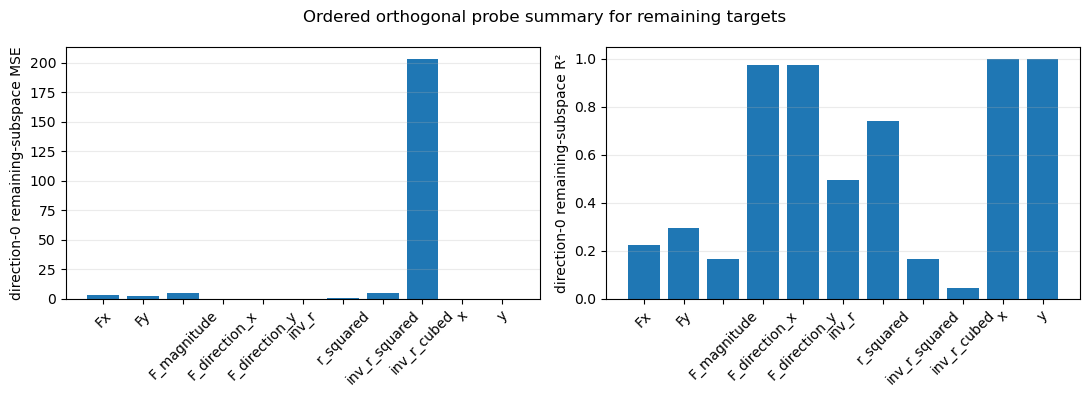

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
target_labels = [row["target"] for row in other_target_summary]
direction_0_mses = [row["direction_0_mse"] for row in other_target_summary]
direction_0_r2s = [row["direction_0_r2"] for row in other_target_summary]

axes[0].bar(target_labels, direction_0_mses)
axes[0].set_ylabel("direction-0 remaining-subspace MSE")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(target_labels, direction_0_r2s)
axes[1].set_ylabel("direction-0 remaining-subspace R²")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("Ordered orthogonal probe summary for remaining targets")
fig.tight_layout()


## Plot Other Physical Quantity Curves


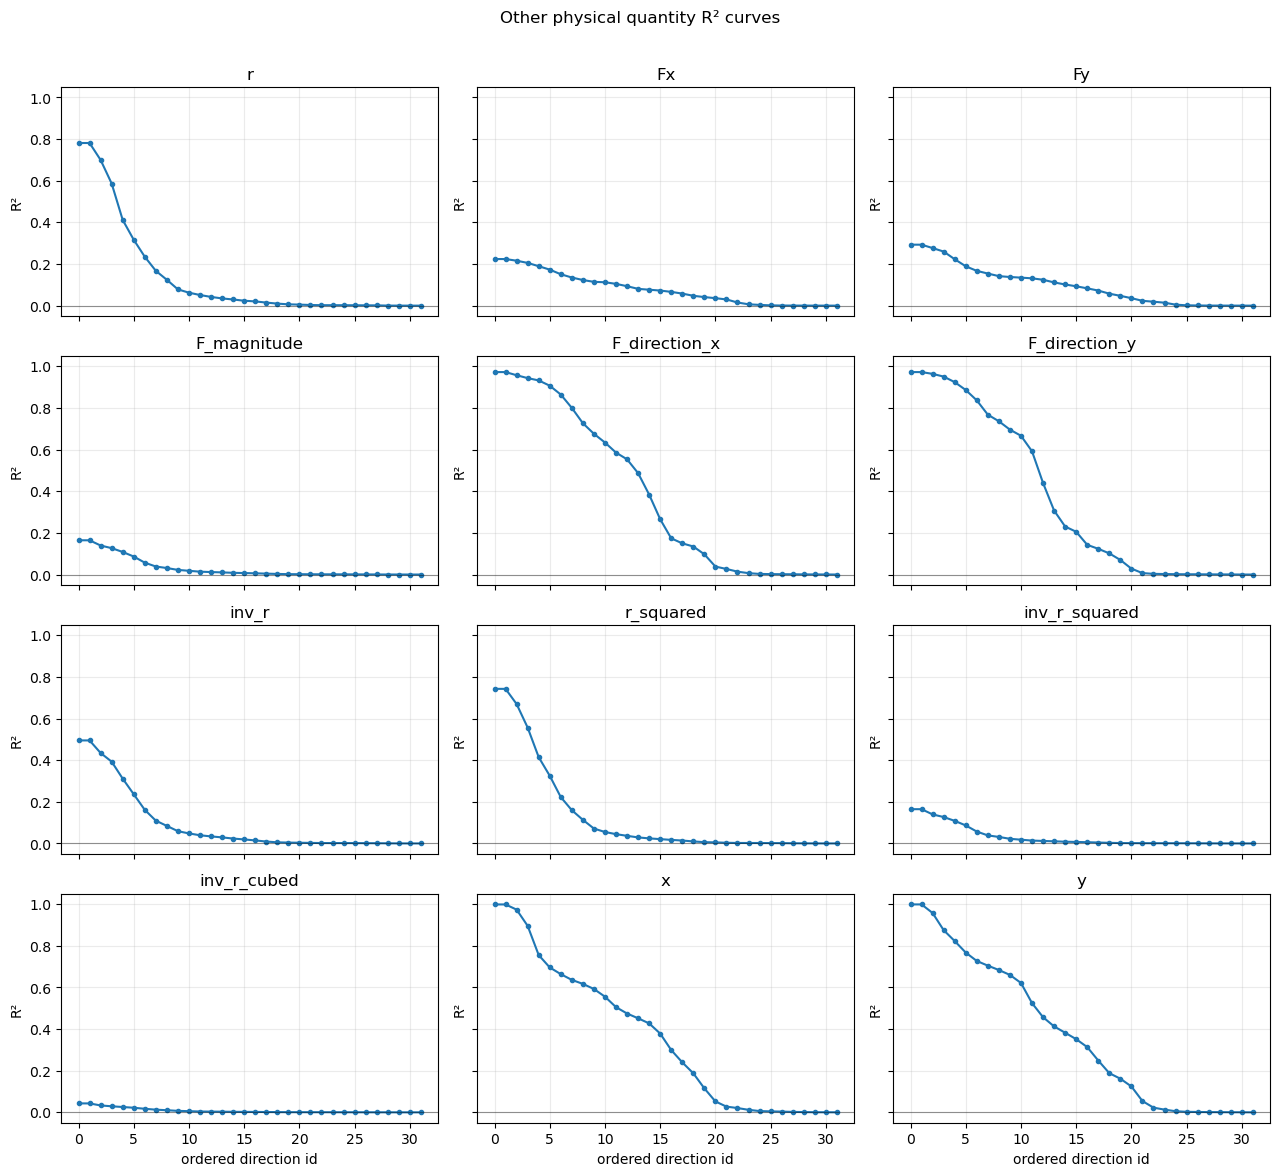

In [16]:
all_target_curve_results = {
    TARGET_NAME: {
        "probe_records": probe_records,
        "target_std": float(y_train.std()),
    }
}
all_target_curve_results.update(other_target_probe_results)

target_plot_order = [TARGET_NAME] + OTHER_TARGET_NAMES
direction_ids = np.arange(V.shape[1])
n_targets = len(target_plot_order)
n_cols = 3
n_rows = int(np.ceil(n_targets / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.3 * n_cols, 2.9 * n_rows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)

for ax, target_name in zip(axes, target_plot_order):
    records = all_target_curve_results[target_name]["probe_records"]
    r2_curve = np.array([row["r2"] for row in records])
    ax.plot(direction_ids, r2_curve, marker="o", markersize=3, linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(target_name)
    ax.set_ylabel("R²")
    ax.grid(alpha=0.25)

for ax in axes[n_targets:]:
    ax.axis("off")

for ax in axes[-n_cols:]:
    ax.set_xlabel("ordered direction id")

fig.suptitle("Other physical quantity R² curves", y=1.01)
fig.tight_layout()


## Dimensionless Keplerian And Newtonian Probes

These probes focus on dimensionless quantities grouped by Keplerian orbital geometry and Newtonian local dynamics.


In [17]:
def load_orbital_params(path="data_cv/orbital_params_chunk_000000.py"):
    namespace = {}
    with open(path, "r") as f:
        exec(f.read(), namespace)
    return namespace["orbital_params"]


all_orbital_params = load_orbital_params()
train_orbital_params = all_orbital_params[:train_inputs.shape[0]]
test_orbital_params = all_orbital_params[train_inputs.shape[0]:train_inputs.shape[0] + test_inputs.shape[0]]

print("loaded orbital params", len(all_orbital_params))
print("train orbital params", len(train_orbital_params))
print("first train params", train_orbital_params[0])


loaded orbital params 200
train orbital params 100
first train params {'e': 0.3336176038, 'a': 1.5804867402, 'b': 1.4899382661, 'c': 0.527278199, 'average_radius': 1.5345447772, 'LRL_x': 0.3336175176, 'LRL_y': 0.0002397503, 'LRL_magnitude': 0.3336176038, 'LRL_angle': 0.0007186382, 'n_x': 0.9999997418, 'n_y': 0.0007186381}


In [18]:
def compute_dimensionless_targets(inputs, orbital_params, dt=0.2, mu=1.0):
    positions = np.asarray(inputs)
    batch_size, time_steps, _ = positions.shape
    x = positions[:, :, 0]
    y = positions[:, :, 1]
    r = np.sqrt(x**2 + y**2)
    r_safe = np.where(r < 1e-10, 1e-10, r)

    a = np.array([p["a"] for p in orbital_params])[:, None]
    e = np.array([p["e"] for p in orbital_params])[:, None]
    e_vec_x = np.array([p["LRL_x"] for p in orbital_params])[:, None]
    e_vec_y = np.array([p["LRL_y"] for p in orbital_params])[:, None]
    n_x = np.array([p["n_x"] for p in orbital_params])[:, None]
    n_y = np.array([p["n_y"] for p in orbital_params])[:, None]
    p_latus = a * (1.0 - e**2)

    # Finite-difference velocity estimate from the sampled positions.
    vx = np.gradient(x, dt, axis=1)
    vy = np.gradient(y, dt, axis=1)
    v2 = vx**2 + vy**2

    radial_velocity = (x * vx + y * vy) / r_safe
    tangential_velocity = (x * vy - y * vx) / r_safe
    local_speed_scale = np.sqrt(mu / r_safe)

    cos_theta = (n_x * x + n_y * y) / r_safe
    sin_theta = (n_x * y - n_y * x) / r_safe
    theta = np.arctan2(sin_theta, cos_theta)

    keplerian = {
        "e": np.repeat(e, time_steps, axis=1),
        "e_vec_x": np.repeat(e_vec_x, time_steps, axis=1),
        "e_vec_y": np.repeat(e_vec_y, time_steps, axis=1),
        "r_over_a": r / a,
        "a_over_r": a / r_safe,
        "x_over_a": x / a,
        "y_over_a": y / a,
        "p_over_r": p_latus / r_safe,
        "r_over_p": r / p_latus,
        "cos_theta": cos_theta,
        "sin_theta": sin_theta,
        "theta": theta,
    }
    newtonian = {
        "r_hat_x": x / r_safe,
        "r_hat_y": y / r_safe,
        "F_hat_x": -x / r_safe,
        "F_hat_y": -y / r_safe,
        "v2_r_over_mu": v2 * r_safe / mu,
        "v_r_over_sqrt_mu_over_r": radial_velocity / local_speed_scale,
        "v_t_over_sqrt_mu_over_r": tangential_velocity / local_speed_scale,
    }
    return {
        "keplerian": {name: value.reshape(-1) for name, value in keplerian.items()},
        "newtonian": {name: value.reshape(-1) for name, value in newtonian.items()},
    }


dimensionless_targets_train = compute_dimensionless_targets(train_inputs.numpy(), train_orbital_params)
dimensionless_targets_test = compute_dimensionless_targets(test_inputs.numpy(), test_orbital_params)

for group_name, values in dimensionless_targets_train.items():
    print(group_name, sorted(values.keys()))
    for target_name, target_values in values.items():
        print(f"  {target_name:28s}", target_values.shape, "mean/std", float(target_values.mean()), float(target_values.std()))


keplerian ['a_over_r', 'cos_theta', 'e', 'e_vec_x', 'e_vec_y', 'p_over_r', 'r_over_a', 'r_over_p', 'sin_theta', 'theta', 'x_over_a', 'y_over_a']
  e                            (9900,) mean/std 0.375423957431 0.2342600754764022
  e_vec_x                      (9900,) mean/std 0.008216904098000003 0.3241635122533662
  e_vec_y                      (9900,) mean/std -0.025973768630000005 0.29999465651063945
  r_over_a                     (9900,) mean/std 1.0871706998855197 0.2999923664444923
  a_over_r                     (9900,) mean/std 1.0136794788176067 0.3936065824386675
  x_over_a                     (9900,) mean/std -0.012611656766788657 0.8093881242744064
  y_over_a                     (9900,) mean/std 0.03210333524393656 0.784625221006203
  p_over_r                     (9900,) mean/std 0.8141358313027232 0.30394372994100066
  r_over_p                     (9900,) mean/std 1.488603611324117 0.7856236849241042
  cos_theta                    (9900,) mean/std -0.34700293166788826 0.67360

In [19]:
dimensionless_probe_results = {}

for group_name, values in dimensionless_targets_train.items():
    dimensionless_probe_results[group_name] = {}
    for target_name, y_dimless in values.items():
        print("\n===", group_name, target_name, "===")
        print("y", y_dimless.shape, "mean/std", float(y_dimless.mean()), float(y_dimless.std()))

        V_dimless, records_dimless = fit_ordered_orthogonal_probe_basis(X_train, y_dimless)
        orthogonality_error_dimless = np.max(np.abs(V_dimless.T @ V_dimless - np.eye(V_dimless.shape[1])))
        dimensionless_probe_results[group_name][target_name] = {
            "V": V_dimless,
            "probe_records": records_dimless,
            "orthogonality_error": orthogonality_error_dimless,
            "target_mean": float(y_dimless.mean()),
            "target_std": float(y_dimless.std()),
        }
        print("direction 0", records_dimless[0])
        print("max orthogonality error", orthogonality_error_dimless)



=== keplerian e ===
y (9900,) mean/std 0.375423957431 0.2342600754764022


direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.04806783842283566, 'r2': 0.12409292379875325, 'intercept': -119.64556870948076, 'weight_norm': 10252.564219915392}
max orthogonality error 5.551115123125783e-16

=== keplerian e_vec_x ===
y (9900,) mean/std 0.008216904098000003 0.3241635122533662


direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.027672125251055342, 'r2': 0.7366615613233948, 'intercept': -615.0557733275863, 'weight_norm': 52532.62561797899}
max orthogonality error 6.661338147750939e-16

=== keplerian e_vec_y ===
y (9900,) mean/std -0.025973768630000005 0.29999465651063945


direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.030860206451437812, 'r2': 0.6570966019773071, 'intercept': -153.33063666061227, 'weight_norm': 13090.12351619404}
max orthogonality error 6.661338147750939e-16

=== keplerian r_over_a ===
y (9900,) mean/std 1.0871706998855197 0.2999923664444923


direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.06187648378958373, 'r2': 0.31244852414519453, 'intercept': -84.45799878745908, 'weight_norm': 7317.172542595243}
max orthogonality error 6.661338147750939e-16

=== keplerian a_over_r ===
y (9900,) mean/std 1.0136794788176067 0.3936065824386675


...

direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.013950623875473215, 'r2': 0.9724617900385012, 'intercept': 229.7501704459619, 'weight_norm': 19627.335036456734}
max orthogonality error 4.440892098500626e-16

=== newtonian F_hat_y ===
y (9900,) mean/std -0.019166074693202972 0.7021116018295288


direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.013565410354206218, 'r2': 0.972481761638556, 'intercept': -213.98792571608578, 'weight_norm': 18285.131297835174}
max orthogonality error 4.440892098500626e-16

=== newtonian v2_r_over_mu ===
y (9900,) mean/std 0.9122475981712341 0.28951507806777954


direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.058954414392804376, 'r2': 0.29664609111041207, 'intercept': 89.86054643427308, 'weight_norm': 7605.195707138321}
max orthogonality error 5.551115123125783e-16

=== newtonian v_r_over_sqrt_mu_over_r ===
y (9900,) mean/std 0.036039937287569046 0.3237956464290619


direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.07442726080891167, 'r2': 0.29011176258557436, 'intercept': 760.68758535957, 'weight_norm': 64982.38017690987}
max orthogonality error 4.440892098500626e-16

=== newtonian v_t_over_sqrt_mu_over_r ===
y (9900,) mean/std 0.8809211254119873 0.173444464802742


direction 0 {'direction_id': 0, 'remaining_dim': 32, 'mse': 0.021740218191848164, 'r2': 0.2773249842124609, 'intercept': 38.79405292667253, 'weight_norm': 3240.859329401816}
max orthogonality error 4.440892098500626e-16


In [20]:
dimensionless_summary = []
for group_name, group_results in dimensionless_probe_results.items():
    for target_name, result in group_results.items():
        records = result["probe_records"]
        dimensionless_summary.append({
            "group": group_name,
            "target": target_name,
            "target_std": result["target_std"],
            "direction_0_mse": float(records[0]["mse"]),
            "direction_0_r2": float(records[0]["r2"]),
            "direction_1_mse": float(records[1]["mse"]),
            "direction_1_r2": float(records[1]["r2"]),
            "last_direction_r2": float(records[-1]["r2"]),
        })

for row in sorted(dimensionless_summary, key=lambda row: (row["group"], -row["direction_0_r2"])):
    print(row)


{'group': 'keplerian', 'target': 'y_over_a', 'target_std': 0.784625221006203, 'direction_0_mse': 0.02138103246439207, 'direction_0_r2': 0.9652700510477423, 'direction_1_mse': 0.02140249451202253, 'direction_1_r2': 0.9652351895030598, 'last_direction_r2': 2.3132087769717202e-06}
{'group': 'keplerian', 'target': 'x_over_a', 'target_std': 0.8093881242744064, 'direction_0_mse': 0.025288177750889186, 'direction_0_r2': 0.9613985267916719, 'direction_1_mse': 0.025301737744006084, 'direction_1_r2': 0.9613778279609312, 'last_direction_r2': 0.0001205000300953385}
{'group': 'keplerian', 'target': 'e_vec_x', 'target_std': 0.3241635122533662, 'direction_0_mse': 0.027672125251055342, 'direction_0_r2': 0.7366615613233948, 'direction_1_mse': 0.027714064769610313, 'direction_1_r2': 0.7362624489590601, 'last_direction_r2': 1.851563979349269e-05}
{'group': 'keplerian', 'target': 'e_vec_y', 'target_std': 0.29999465651063945, 'direction_0_mse': 0.030860206451437812, 'direction_0_r2': 0.6570966019773071, 'd

## Plot Dimensionless Curves By Mechanics Type


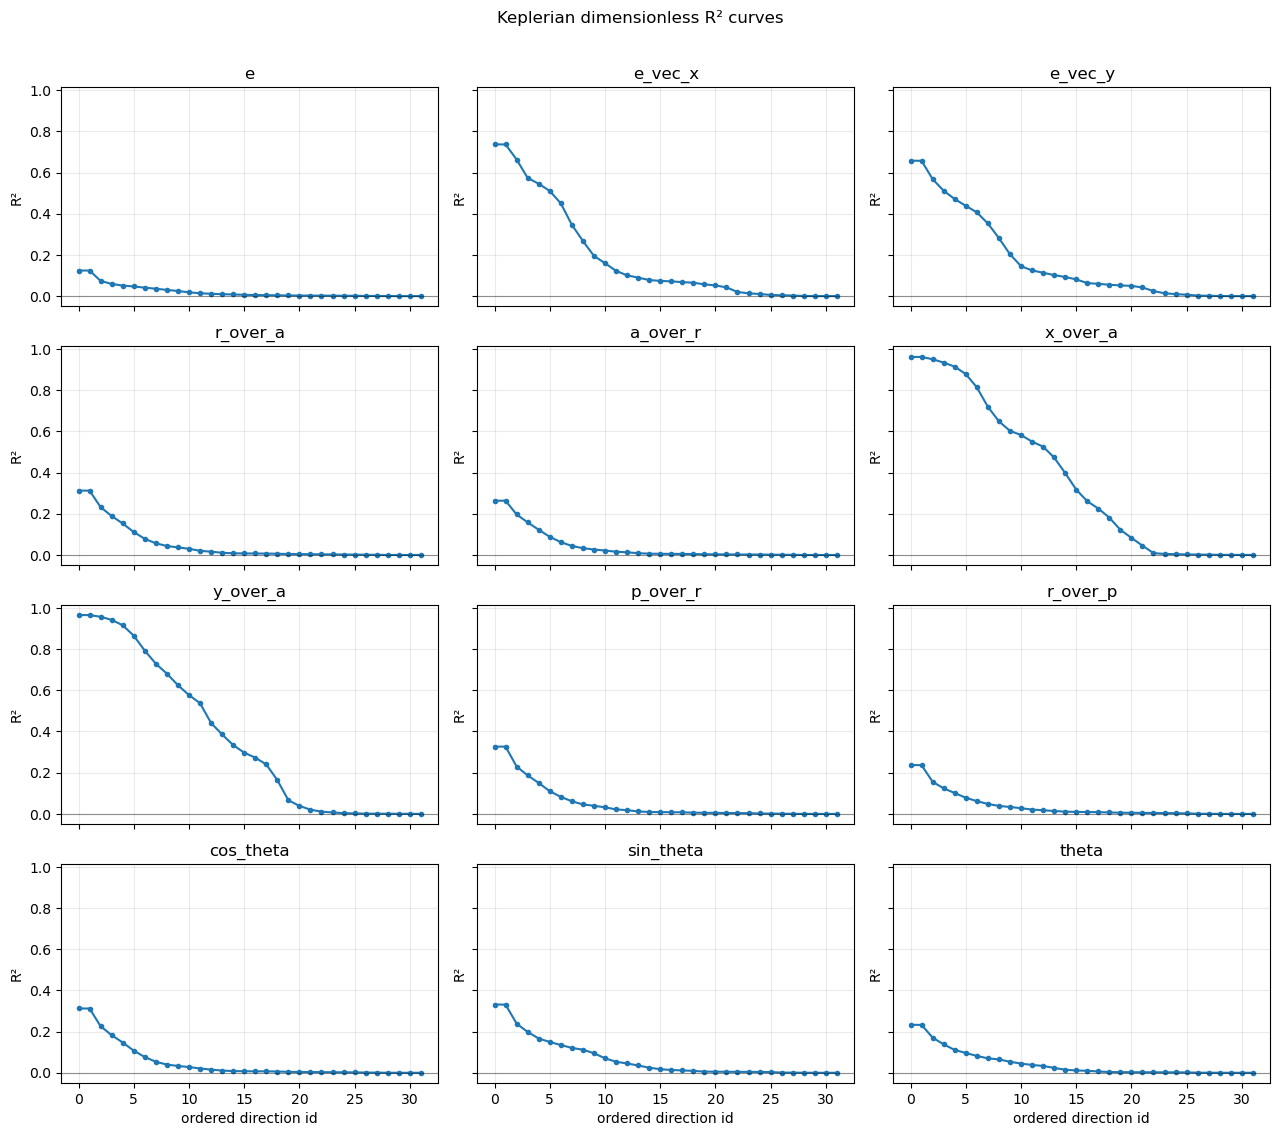

In [21]:
group_name = "keplerian"
group_results = dimensionless_probe_results[group_name]
target_names = list(group_results.keys())
n_targets_dimless = len(target_names)
n_cols_dimless = 3
n_rows_dimless = int(np.ceil(n_targets_dimless / n_cols_dimless))

fig, axes = plt.subplots(n_rows_dimless, n_cols_dimless, figsize=(4.3 * n_cols_dimless, 2.8 * n_rows_dimless), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, target_name in zip(axes, target_names):
    records = group_results[target_name]["probe_records"]
    r2_curve = np.array([row["r2"] for row in records])
    ax.plot(direction_ids, r2_curve, marker="o", markersize=3, linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(target_name)
    ax.set_ylabel("R²")
    ax.grid(alpha=0.25)

for ax in axes[n_targets_dimless:]:
    ax.axis("off")
for ax in axes[-n_cols_dimless:]:
    ax.set_xlabel("ordered direction id")

fig.suptitle("Keplerian dimensionless R² curves", y=1.01)
fig.tight_layout()


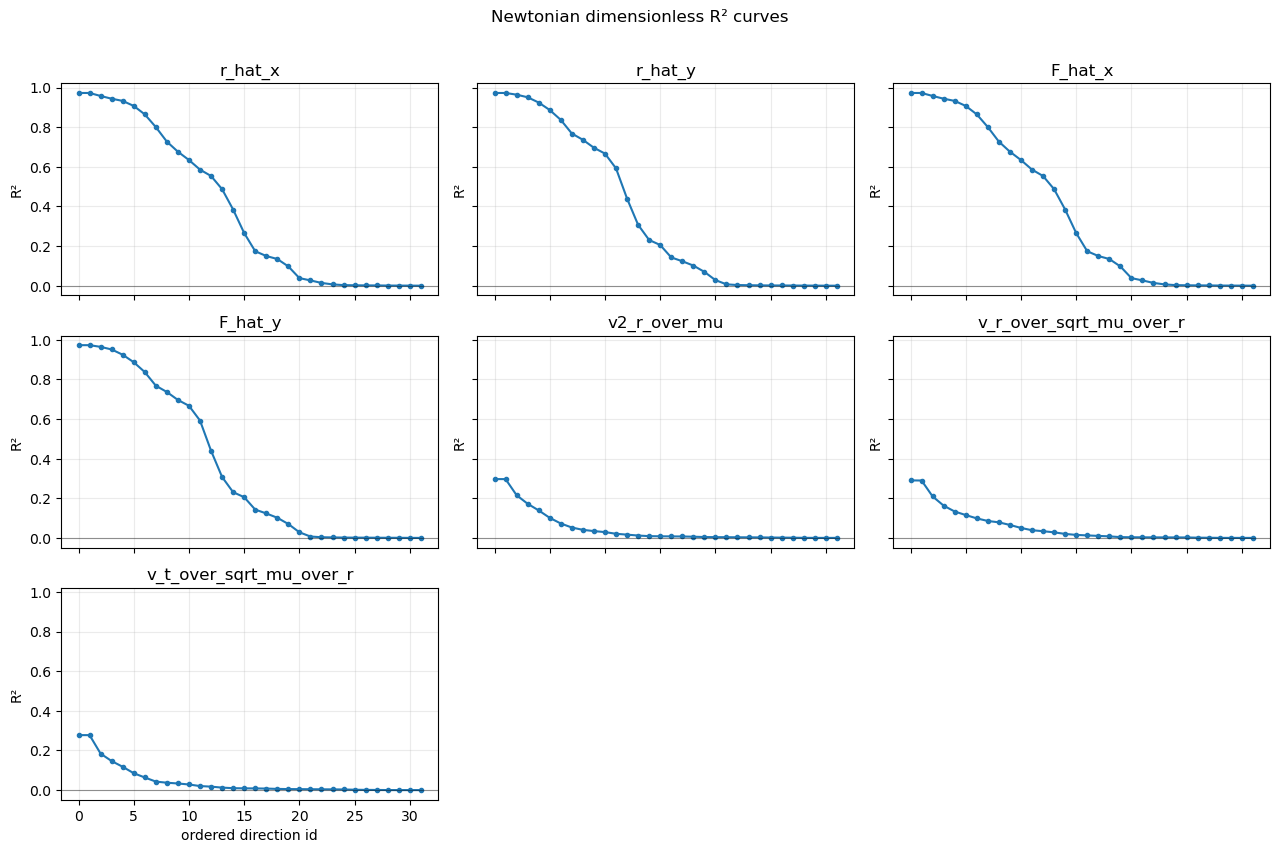

In [22]:
group_name = "newtonian"
group_results = dimensionless_probe_results[group_name]
target_names = list(group_results.keys())
n_targets_dimless = len(target_names)
n_cols_dimless = 3
n_rows_dimless = int(np.ceil(n_targets_dimless / n_cols_dimless))

fig, axes = plt.subplots(n_rows_dimless, n_cols_dimless, figsize=(4.3 * n_cols_dimless, 2.8 * n_rows_dimless), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, target_name in zip(axes, target_names):
    records = group_results[target_name]["probe_records"]
    r2_curve = np.array([row["r2"] for row in records])
    ax.plot(direction_ids, r2_curve, marker="o", markersize=3, linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(target_name)
    ax.set_ylabel("R²")
    ax.grid(alpha=0.25)

for ax in axes[n_targets_dimless:]:
    ax.axis("off")
for ax in axes[-n_cols_dimless:]:
    ax.set_xlabel("ordered direction id")

fig.suptitle("Newtonian dimensionless R² curves", y=1.01)
fig.tight_layout()


## Layerwise Direct Linear Probes

Probe every available model layer/source with ordinary direct linear probes, so we can compare where each physical quantity is most linearly readable.


In [23]:
@torch.no_grad()
def extract_all_gptcv_latents(model, inputs):
    model.eval()
    x = inputs.to(device)
    if x.dim() == 2:
        x = x.unsqueeze(-1)

    _, time_steps, _ = x.shape
    pos = torch.arange(0, time_steps, dtype=torch.long, device=x.device)

    latents = {}
    h = model.input_embedding(x)
    latents["input_embed"] = h.cpu().numpy()

    h = model.transformer.drop(h + model.transformer.wpe(pos))
    latents["after_pos_emb"] = h.cpu().numpy()

    for block_idx, block in enumerate(model.transformer.h):
        h = block(h)
        latents[f"block_{block_idx}_after_mlp_merge"] = h.cpu().numpy()

    h = model.transformer.ln_f(h)
    latents["after_ln_f"] = h.cpu().numpy()
    return latents


layer_latents_train = extract_all_gptcv_latents(model, train_inputs)
layer_names = list(layer_latents_train.keys())

print("transformer blocks", len(model.transformer.h))
print("layer/source names", layer_names)
for layer_name, layer_z in layer_latents_train.items():
    print(f"{layer_name:28s}", layer_z.shape)


transformer blocks 2
layer/source names ['input_embed', 'after_pos_emb', 'block_0_after_mlp_merge', 'block_1_after_mlp_merge', 'after_ln_f']
input_embed                  (100, 99, 32)
after_pos_emb                (100, 99, 32)
block_0_after_mlp_merge      (100, 99, 32)
block_1_after_mlp_merge      (100, 99, 32)
after_ln_f                   (100, 99, 32)


In [24]:
def run_layerwise_direct_probes(layer_latents, target_values_by_name):
    results = {}
    for layer_name, layer_z in layer_latents.items():
        X_layer = layer_z.reshape(-1, layer_z.shape[-1])
        layer_results = {}
        for target_name, y_values in target_values_by_name.items():
            probe = LinearRegression(fit_intercept=True)
            probe.fit(X_layer, y_values)
            pred = probe.predict(X_layer)
            layer_results[target_name] = {
                "mse": float(mean_squared_error(y_values, pred)),
                "r2": float(r2_score(y_values, pred)),
            }
        results[layer_name] = layer_results
    return results


physical_target_values = {name: dynamic_values_train[name].reshape(-1) for name in ALL_TARGET_NAMES}
keplerian_target_values = dimensionless_targets_train["keplerian"]
newtonian_target_values = dimensionless_targets_train["newtonian"]

layerwise_probe_results = {
    "physical": run_layerwise_direct_probes(layer_latents_train, physical_target_values),
    "keplerian_dimensionless": run_layerwise_direct_probes(layer_latents_train, keplerian_target_values),
    "newtonian_dimensionless": run_layerwise_direct_probes(layer_latents_train, newtonian_target_values),
}

for group_name, group_results in layerwise_probe_results.items():
    print("\n", group_name)
    first_layer = layer_names[0]
    for target_name, result in group_results[first_layer].items():
        best_layer = max(layer_names, key=lambda name: group_results[name][target_name]["r2"])
        best_r2 = group_results[best_layer][target_name]["r2"]
        print(f"  {target_name:28s} best {best_layer:28s} R²={best_r2:.4f}")



 physical
  Fx                           best block_1_after_mlp_merge      R²=0.2639
  Fy                           best block_1_after_mlp_merge      R²=0.3374
  F_magnitude                  best block_1_after_mlp_merge      R²=0.2050
  F_direction_x                best block_0_after_mlp_merge      R²=0.9833
  F_direction_y                best block_1_after_mlp_merge      R²=0.9824
  r                            best block_1_after_mlp_merge      R²=0.8549
  inv_r                        best block_1_after_mlp_merge      R²=0.5904
  r_squared                    best block_1_after_mlp_merge      R²=0.7792
  inv_r_squared                best block_1_after_mlp_merge      R²=0.2050
  inv_r_cubed                  best block_1_after_mlp_merge      R²=0.0565
  x                            best input_embed                  R²=1.0000
  y                            best input_embed                  R²=1.0000

 keplerian_dimensionless
  e                            best block_0_after_mlp_merge    

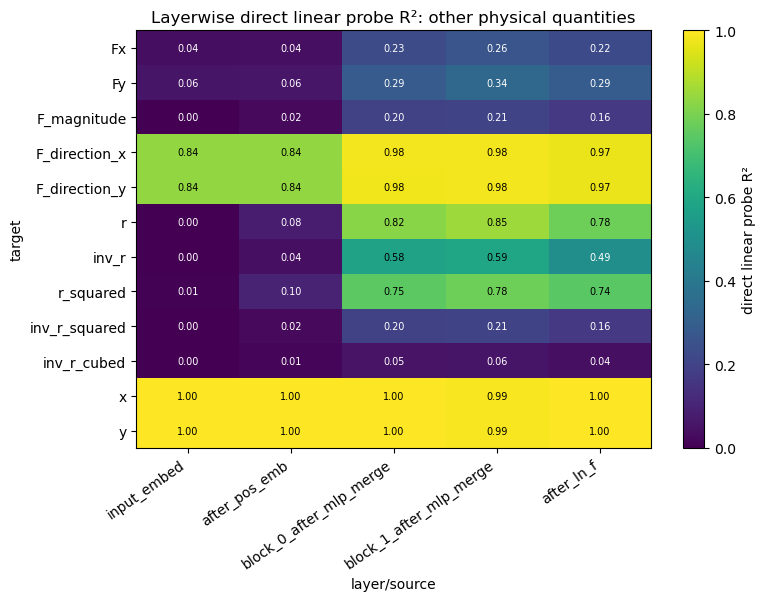

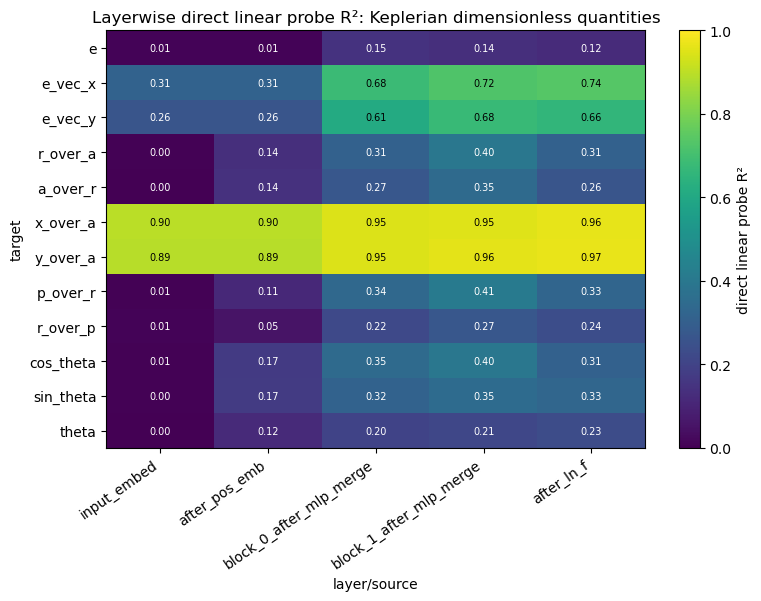

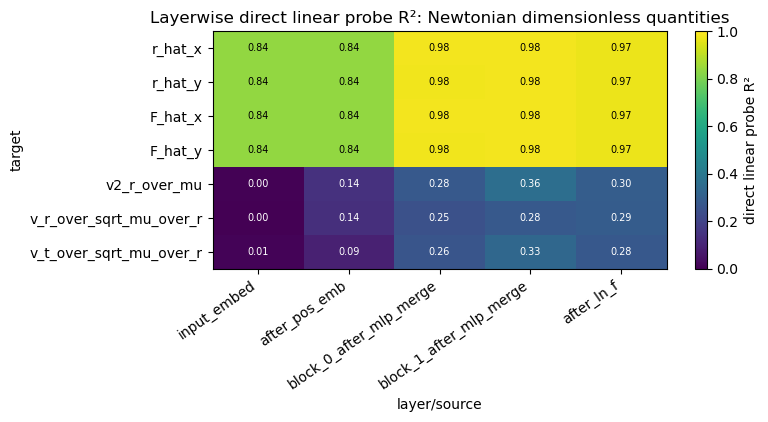

In [25]:
def plot_layerwise_probe_heatmap(group_name, group_results, title):
    target_names = list(next(iter(group_results.values())).keys())
    r2_matrix = np.array([
        [group_results[layer_name][target_name]["r2"] for layer_name in layer_names]
        for target_name in target_names
    ])

    fig_width = max(8, 1.55 * len(layer_names))
    fig_height = max(4, 0.36 * len(target_names) + 1.8)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    vmin = min(0.0, float(np.nanmin(r2_matrix)))
    im = ax.imshow(r2_matrix, aspect="auto", cmap="viridis", vmin=vmin, vmax=1.0)
    ax.set_xticks(np.arange(len(layer_names)))
    ax.set_xticklabels(layer_names, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(target_names)))
    ax.set_yticklabels(target_names)
    ax.set_title(title)
    ax.set_xlabel("layer/source")
    ax.set_ylabel("target")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("direct linear probe R²")

    for y_idx in range(r2_matrix.shape[0]):
        for x_idx in range(r2_matrix.shape[1]):
            value = r2_matrix[y_idx, x_idx]
            text_color = "white" if value < 0.55 else "black"
            ax.text(x_idx, y_idx, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=7)

    fig.tight_layout()
    return fig, ax, r2_matrix


physical_layerwise_r2_fig = plot_layerwise_probe_heatmap(
    "physical",
    layerwise_probe_results["physical"],
    "Layerwise direct linear probe R²: other physical quantities",
)
keplerian_layerwise_r2_fig = plot_layerwise_probe_heatmap(
    "keplerian_dimensionless",
    layerwise_probe_results["keplerian_dimensionless"],
    "Layerwise direct linear probe R²: Keplerian dimensionless quantities",
)
newtonian_layerwise_r2_fig = plot_layerwise_probe_heatmap(
    "newtonian_dimensionless",
    layerwise_probe_results["newtonian_dimensionless"],
    "Layerwise direct linear probe R²: Newtonian dimensionless quantities",
)


## Project Latents Into Orthogonal Probe Coordinates


In [26]:
coords_train = z_train @ V
coords_test = z_test @ V

print("coords_train", coords_train.shape)
print("coords_test", coords_test.shape)


coords_train (100, 99, 32)
coords_test (100, 99, 32)


In [27]:
# Debug: projected orthogonal-coordinate shapes
print("V", V.shape)
print("z_train", z_train.shape, "-> coords_train", coords_train.shape)
print("z_test", z_test.shape, "-> coords_test", coords_test.shape)
print("coords_train first trajectory", coords_train[TRAJECTORY_ID].shape)
print("first five coordinate stds", np.std(coords_train.reshape(-1, coords_train.shape[-1]), axis=0)[:5])


V (32, 32)
z_train (100, 99, 32) -> coords_train (100, 99, 32)
z_test (100, 99, 32) -> coords_test (100, 99, 32)
coords_train first trajectory (99, 32)
first five coordinate stds [6.75907044e-05 5.44616193e-01 5.04581085e-01 3.62623162e-01
 3.36085084e-01]


## Save Probe Results

In [28]:
result_path = os.path.join(args.output_dir, f"normal_orthogonal_probe_basis_{LATENT_SOURCE}_target_{TARGET_NAME}.npz")
np.savez(
    result_path,
    config=vars(args),
    target_name=TARGET_NAME,
    latent_source=LATENT_SOURCE,
    V=V,
    probe_records=np.array(probe_records, dtype=object),
    train_losses=np.array(train_losses),
    test_losses=np.array(test_losses),
    coords_train=coords_train,
    coords_test=coords_test,
    orthogonality_error=orthogonality_error,
)
print(f"Saved orthogonal probe results to {result_path}")

Saved orthogonal probe results to results/orthogonal_linear_probe_basis_normal/normal_orthogonal_probe_basis_after_ln_f_target_r.npz
